In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Pipeline & preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Models (scikit-learn)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from catboost import CatBoostClassifier
# Boosting libraries
from xgboost import XGBClassifier
import lightgbm as lgb
# Metrics
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss

In [3]:
eye_df = pd.read_csv('EyeTracking_FeaturesExtracted.csv')
gsr_df = pd.read_csv('GSR_FeaturesExtracted.csv')
print("EyeTracking ve GSR veri setleri başarıyla yüklendi.\n")

EyeTracking ve GSR veri setleri başarıyla yüklendi.



In [4]:
eye_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Quad_Cat                 312 non-null    int64  
 1   Num_of_Fixations         312 non-null    float64
 2   Mean_Fixation_Duration   312 non-null    float64
 3   SD_Fixation_Duration     312 non-null    float64
 4   Skew_Fixation_Duration   312 non-null    float64
 5   Max_Fixation_Duration    312 non-null    int64  
 6   First_Fixation_Duration  312 non-null    int64  
 7   Num_of_Saccade           312 non-null    float64
 8   Mean_Saccade_Duration    312 non-null    float64
 9   SD_Saccade_Duration      312 non-null    float64
 10  Skew_Saccade_Duration    312 non-null    float64
 11  Max_Saccade_Duration     312 non-null    int64  
 12  Mean_Saccade_Amplitude   312 non-null    float64
 13  SD_Saccade_Amplitude     312 non-null    float64
 14  Skew_Saccade_Amplitude   3

Eye_Tracking veri setinde 312 satır veri  ve 49 adet feature var. Burada quad Cat bizim target feature'mız olacak.
312 adet satırımız var.  
SD_Blink_Duration        275 non-null    float64
Skew_Blink_Duration      275 non-null    float64  
Max_Blink_Duration       301
Mean_Blink_Duration      301
Bu özelliklerde eksik özelliklerimiz var.

In [5]:
eye_df.head()

,Quad_Cat,Num_of_Fixations,Mean_Fixation_Duration,SD_Fixation_Duration,Skew_Fixation_Duration,Max_Fixation_Duration,First_Fixation_Duration,Num_of_Saccade,Mean_Saccade_Duration,SD_Saccade_Duration,...,Skew_Microsac_Dir,Max_Microsac_Dir,Mean_Microsac_H_Amp,SD_Microsac_H_Amp,Skew_Microsac_H_Amp,Max_Microsac_H_Amp,Mean_Microsac_V_Amp,SD_Microsac_V_Amp,Skew_Microsac_V_Amp,Max_Microsac_V_Amp
0,1,0.605556,1208.440367,1013.049251,2.080900,6127,1640,0.605556,438.064220,517.053212,...,-0.047816,179.719495,0.419874,25.214209,3.156580,220.069746,-0.182289,8.975206,0.107803,45.070474
1,0,0.459184,1796.311111,1880.259542,2.346293,9773,556,0.448980,392.000000,426.838023,...,-0.161061,179.563907,-4.596920,74.737290,-8.745373,144.173940,0.660248,10.523471,3.971437,81.150671
2,0,0.480000,1617.694444,1895.391401,1.633123,7573,671,0.466667,481.314286,528.473650,...,-0.214484,179.789091,-1.217540,17.351371,-2.922202,35.323715,-1.158868,14.659309,-5.198588,26.595861
3,3,0.454545,1858.763636,2711.244828,3.296111,14840,1804,0.446281,349.240741,427.406260,...,0.083588,179.846777,-0.908321,25.611097,-3.302714,122.294054,0.094660,3.775847,1.529565,29.637883
4,1,0.527778,1582.126316,1520.578818,1.862892,7526,1315,0.522222,311.531915,355.951480,...,0.219166,179.868585,-2.472084,17.046195,-2.911459,55.629425,-0.538492,5.075856,-2.305319,17.997401


In [6]:
gsr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Quad_Cat           312 non-null    int64  
 1   Mean               312 non-null    float64
 2   SD                 312 non-null    float64
 3   Variance           312 non-null    float64
 4   Minimum            312 non-null    float64
 5   Maximum            312 non-null    float64
 6   Number of Peaks    312 non-null    float64
 7   Number of Valleys  312 non-null    float64
 8   Ratio              312 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 22.1 KB


In [7]:
gsr_df.head()

,Quad_Cat,Mean,SD,Variance,Minimum,Maximum,Number of Peaks,Number of Valleys,Ratio
0,1,3.560146,0.139966,0.019591,3.317403,3.982484,0.000019,0.000019,5.300000e-11
1,0,5.567496,0.659287,0.434660,4.043869,7.146960,0.000036,0.000036,1.880000e-10
2,0,4.072888,0.530539,0.281472,2.393337,4.711197,0.000041,0.000041,2.820000e-10
3,3,5.407625,0.891521,0.794809,3.213556,7.700064,0.000041,0.000041,1.910000e-10
4,1,3.232517,0.159728,0.025513,2.973926,3.608285,0.000030,0.000030,8.350000e-11


In [8]:
eye_missing_values = eye_df.isnull().sum()
print(eye_missing_values)
eye_df[eye_df.isnull().any(axis=1)].isnull()


Quad_Cat                    0
Num_of_Fixations            0
Mean_Fixation_Duration      0
SD_Fixation_Duration        0
Skew_Fixation_Duration      0
Max_Fixation_Duration       0
First_Fixation_Duration     0
Num_of_Saccade              0
Mean_Saccade_Duration       0
SD_Saccade_Duration         0
Skew_Saccade_Duration       0
Max_Saccade_Duration        0
Mean_Saccade_Amplitude      0
SD_Saccade_Amplitude        0
Skew_Saccade_Amplitude      0
Max_Saccade_Amplitude       0
Mean_Saccade_Direction      0
SD_Saccade_Direction        0
Skew_Saccade_Direction      0
Max_Saccade_Direction       0
Mean_Saccade_Length         0
SD_Saccade_Length           0
Skew_Saccade_Length         0
Max_Saccade_Length          0
Num_of_Blink                0
Mean_Blink_Duration        11
SD_Blink_Duration          37
Skew_Blink_Duration        37
Max_Blink_Duration         11
Num_of_Microsac             0
Mean_Microsac_Peak_Vel      0
SD_Microsac_Peak_Vel        0
Skew_Microsac_Peak_Vel      0
Max_Micros

,Quad_Cat,Num_of_Fixations,Mean_Fixation_Duration,SD_Fixation_Duration,Skew_Fixation_Duration,Max_Fixation_Duration,First_Fixation_Duration,Num_of_Saccade,Mean_Saccade_Duration,SD_Saccade_Duration,...,Skew_Microsac_Dir,Max_Microsac_Dir,Mean_Microsac_H_Amp,SD_Microsac_H_Amp,Skew_Microsac_H_Amp,Max_Microsac_H_Amp,Mean_Microsac_V_Amp,SD_Microsac_V_Amp,Skew_Microsac_V_Amp,Max_Microsac_V_Amp
37,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
38,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
40,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
42,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
70,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
83,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
85,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
86,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
eye_df[eye_df.isnull().any(axis=1)]

,Quad_Cat,Num_of_Fixations,Mean_Fixation_Duration,SD_Fixation_Duration,Skew_Fixation_Duration,Max_Fixation_Duration,First_Fixation_Duration,Num_of_Saccade,Mean_Saccade_Duration,SD_Saccade_Duration,...,Skew_Microsac_Dir,Max_Microsac_Dir,Mean_Microsac_H_Amp,SD_Microsac_H_Amp,Skew_Microsac_H_Amp,Max_Microsac_H_Amp,Mean_Microsac_V_Amp,SD_Microsac_V_Amp,Skew_Microsac_V_Amp,Max_Microsac_V_Amp
37,0,0.540816,1563.037736,1484.103070,1.763989,6438,401,0.530612,292.230769,254.308414,...,0.115239,179.471784,0.249305,18.637375,0.077688,75.895026,-0.098685,4.695076,-0.603813,24.485316
38,0,0.400000,2318.333333,4360.135693,3.906468,23508,396,0.386667,195.068965,232.367002,...,0.122239,179.873395,0.790300,14.609002,3.980288,114.200483,-0.046100,1.525113,2.046203,8.277569
40,1,0.522222,1552.212766,1428.239889,2.156268,8839,3052,0.516667,364.268817,402.854574,...,0.048416,179.969301,0.903991,21.616719,0.099433,95.973269,-0.219054,6.983753,-0.430635,39.761907
41,2,0.436047,1878.960000,2041.099614,3.523756,14514,2443,0.430233,417.756757,476.447953,...,-0.007991,179.929700,0.780571,29.654468,-0.607744,151.291906,-0.005770,7.650691,-0.966354,34.300570
42,2,0.528736,1661.097826,1538.296461,1.604469,7066,5455,0.534483,222.655914,307.576908,...,0.079651,179.913590,0.075929,14.473157,-0.757164,120.554329,0.000813,4.064359,-0.210334,30.260882
43,2,0.439655,2112.764706,1997.337464,1.887065,9181,935,0.431034,175.260000,220.653834,...,0.000007,179.631070,0.266478,12.810401,1.543504,112.120396,-0.028036,2.891087,-2.883523,16.216397
70,3,0.137500,6801.545455,9439.288420,1.601494,31872,11445,0.125000,532.800000,293.168817,...,0.161146,179.407479,-0.931264,22.047066,1.063781,84.697439,-0.169885,4.805522,0.496775,20.203617
83,3,0.480000,1673.333333,1531.202795,2.074883,6901,1488,0.480000,412.000000,410.915007,...,0.025147,179.203252,1.013782,14.654473,-0.176505,69.827183,-0.154444,5.559463,0.244860,27.168202
85,0,0.397959,1988.025641,1559.212799,1.177445,6039,1168,0.387755,540.447368,471.667582,...,0.023574,179.785253,1.021161,19.958734,1.807170,123.260458,-0.123252,1.980730,0.903246,12.311695
86,0,0.573333,1302.209302,1024.126424,1.151937,3801,733,0.573333,442.279070,399.747261,...,0.012899,179.533803,0.642910,15.329282,0.520644,51.097658,-0.043023,4.502580,0.228175,16.852667


In [10]:
missing_cols = eye_df.columns[eye_df.isnull().any()]
eye_df.loc[eye_df.isnull().any(axis=1), missing_cols]

,Mean_Blink_Duration,SD_Blink_Duration,Skew_Blink_Duration,Max_Blink_Duration
37,54.0,NaN,NaN,54.0
38,74.0,NaN,NaN,74.0
40,86.0,NaN,NaN,86.0
41,71.0,NaN,NaN,71.0
42,90.0,NaN,NaN,90.0
43,60.0,NaN,NaN,60.0
70,NaN,NaN,NaN,NaN
83,70.0,NaN,NaN,70.0
85,118.0,NaN,NaN,118.0
86,NaN,NaN,NaN,NaN


In [11]:
dolu_veriler = eye_df.loc[eye_df[missing_cols].notnull().all(axis=1), missing_cols]

print(dolu_veriler)

     Mean_Blink_Duration  SD_Blink_Duration  Skew_Blink_Duration  \
0              77.468750          32.272014             2.743090   
1             104.500000          89.992777             1.322178   
2              67.500000          14.010710             0.682107   
3              59.500000           8.888194             0.469973   
4              89.217391          45.167322             1.657277   
..                   ...                ...                  ...   
307            79.000000           9.528903             0.010402   
308           131.214286          63.956931             1.408783   
309            94.866667          32.923866            -0.207254   
310           211.692308         279.820593             2.649553   
311           132.666667           9.073772             0.338109   

     Max_Blink_Duration  
0                 219.0  
1                 287.0  
2                  92.0  
3                  72.0  
4                 213.0  
..                  ...  
3

Max_Blink ya da Mean Blink duration için NaN olan satırların hepsinde SD Blink_lerde NaN durumda. Zaten SD Blinkleri NaNlar silinirse max_Blinkler de otomatik olarak silinecek. 312'den 37 tane sileceğiz. İki ayrı veriseti oluşturacağım. Birisi medyan ya da ortalama ile doldurma birisi de yine hepsini silindiği.

In [12]:
blink_columns = [
    'Mean_Blink_Duration',
    'SD_Blink_Duration',
    'Skew_Blink_Duration',
    'Max_Blink_Duration'
]

# Orijinal veride, bu sütunlardan herhangi birinin değerinin 0 olduğu satırları filtrele
zero_value_rows = eye_df[
    (eye_df['Mean_Blink_Duration'] == 0) |
    (eye_df['SD_Blink_Duration'] == 0) |
    (eye_df['Skew_Blink_Duration'] == 0) |
    (eye_df['Max_Blink_Duration'] == 0)
]
if zero_value_rows.empty:
    print("Belirtilen sütunlarda ('Mean_Blink_Duration', 'SD_Blink_Duration', 'Skew_Blink_Duration', 'Max_Blink_Duration')")
    print("halihazırda '0' değerine sahip hiçbir satır bulunamadı.")
else:
    columns_to_display = ['Num_of_Blink'] + blink_columns
    print(f"--- Toplam {len(zero_value_rows)} satırda belirtilen sütunlardan en az birinde '0' değeri bulundu ---")
    print(zero_value_rows[columns_to_display].to_string())

--- Toplam 13 satırda belirtilen sütunlardan en az birinde '0' değeri bulundu ---
     Num_of_Blink  Mean_Blink_Duration  SD_Blink_Duration  Skew_Blink_Duration  Max_Blink_Duration
15       0.016529                120.0          29.698485                  0.0               141.0
22       0.025000                133.5          28.991378                  0.0               154.0
36       0.011111                100.0           2.828427                  0.0               102.0
89       0.017442                 73.0          16.000000                  0.0                89.0
91       0.017241                130.5          41.719300                  0.0               160.0
97       0.020408                221.0         171.119841                  0.0               342.0
184      0.011111                104.5          50.204581                  0.0               140.0
189      0.012422                102.5          38.890873                  0.0               130.0
192      0.011111          

0 olsa 0 değeri veriliyor. NaN ise tamamen rastgele veriler geliyor.

In [13]:
# Göz Takibi veri seti için 'stres' sütununu oluştur
eye_df['stres'] = eye_df['Quad_Cat'].apply(lambda x: 1 if x == 3 else 0)
print("-> Göz Takibi veri seti etiketlendi.")

# Quad_Cat artık gereksiz, sil
eye_df = eye_df.drop(columns=['Quad_Cat'])

# GSR Veri Seti için 'stres' sütununu oluştur
gsr_df['stres'] = gsr_df['Quad_Cat'].apply(lambda x: 1 if x == 3 else 0)
print("-> GSR veri seti etiketlendi.")

# Quad_Cat artık gereksiz, sil
gsr_df = gsr_df.drop(columns=['Quad_Cat'])

# GSR'dan sadece feature'ları al (etiket tekrar etmesin)
gsr_features_only = gsr_df.drop(columns=['stres'])
print("-> Birleştirme için GSR veri setinden tekrar eden sütunlar kaldırıldı.")

# Etiketlenmiş Eye verisi + GSR feature'ları birleştir
birlesik_df = pd.concat([eye_df, gsr_features_only], axis=1)
print("-> İki veri seti başarıyla birleştirildi.\n")

print(f"Final Veri Setinin Boyutu: {birlesik_df.shape}")


-> Göz Takibi veri seti etiketlendi.
-> GSR veri seti etiketlendi.
-> Birleştirme için GSR veri setinden tekrar eden sütunlar kaldırıldı.
-> İki veri seti başarıyla birleştirildi.

Final Veri Setinin Boyutu: (312, 58)


59 adet feature oldu. Target Feature ['stres] kalanı eğitim veri seti için kullanılacak. Birbiriyle aşırı korelasyonlu featurelar var. Bunları silmek gerekiyor.

In [14]:
threshold = 0.8

corr_matrix = birlesik_df.select_dtypes(include=[np.number]).corr().abs()

# Üst üçgen maskesi
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Eşik üstü korelasyonlar
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"] >= threshold
].sort_values(by="Correlation", ascending=False)

print(high_corr_pairs)


                   Feature_1               Feature_2  Correlation
714    Max_Saccade_Amplitude      Max_Saccade_Length     1.000000
625     SD_Saccade_Amplitude       SD_Saccade_Length     1.000000
670   Skew_Saccade_Amplitude     Skew_Saccade_Length     1.000000
579   Mean_Saccade_Amplitude     Mean_Saccade_Length     1.000000
5           Num_of_Fixations          Num_of_Saccade     0.999119
1384        SD_Microsac_Ampl       SD_Microsac_H_Amp     0.986811
1650         Number of Peaks       Number of Valleys     0.985503
1627                    Mean                 Minimum     0.982255
1628                    Mean                 Maximum     0.980993
1643                 Minimum                 Maximum     0.943303
381    Mean_Saccade_Duration  Mean_Saccade_Amplitude     0.925925
389    Mean_Saccade_Duration     Mean_Saccade_Length     0.925925
1092     Mean_Blink_Duration       SD_Blink_Duration     0.925195
429      SD_Saccade_Duration    Max_Saccade_Duration     0.920684
114     SD

In [15]:
to_drop = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] >= threshold)
]

print("Silinecek feature sayısı:", len(to_drop))
print(to_drop)


Silinecek feature sayısı: 25
['SD_Fixation_Duration', 'Max_Fixation_Duration', 'Num_of_Saccade', 'SD_Saccade_Duration', 'Max_Saccade_Duration', 'Mean_Saccade_Amplitude', 'SD_Saccade_Amplitude', 'Max_Saccade_Amplitude', 'Skew_Saccade_Direction', 'Mean_Saccade_Length', 'SD_Saccade_Length', 'Skew_Saccade_Length', 'Max_Saccade_Length', 'SD_Blink_Duration', 'Max_Blink_Duration', 'Max_Microsac_Peak_Vel', 'Mean_Microsac_Ampl', 'Max_Microsac_Ampl', 'Skew_Microsac_Dir', 'SD_Microsac_H_Amp', 'Variance', 'Minimum', 'Maximum', 'Number of Valleys', 'Ratio']


In [16]:
birlesik_df_reduced = birlesik_df.drop(columns=to_drop)

print("Eski shape:", birlesik_df.shape)
print("Yeni shape:", birlesik_df_reduced.shape)


Eski shape: (312, 58)
Yeni shape: (312, 33)


In [17]:

df = birlesik_df_reduced.copy()

categorical_columns = ['stres']
continuous_numeric_columns = []
non_continuous_numeric_columns = []

for col in df.columns:
    if col in categorical_columns:
        continue

    # numeric kolonlar
    if np.issubdtype(df[col].dtype, np.number):
        if df[col].nunique(dropna=True) > 25:
            continuous_numeric_columns.append(col)
        else:
            non_continuous_numeric_columns.append(col)

print("Categorical columns:")
print(categorical_columns)
print("Count:", len(categorical_columns))

print("\nContinuous numeric columns (unique > 25):")
print(continuous_numeric_columns)
print("Count:", len(continuous_numeric_columns))

print("\nNumeric but NOT continuous (unique <= 25):")
print(non_continuous_numeric_columns)
print("Count:", len(non_continuous_numeric_columns))


Categorical columns:
['stres']
Count: 1

Continuous numeric columns (unique > 25):
['Num_of_Fixations', 'Mean_Fixation_Duration', 'Skew_Fixation_Duration', 'First_Fixation_Duration', 'Mean_Saccade_Duration', 'Skew_Saccade_Duration', 'Skew_Saccade_Amplitude', 'Mean_Saccade_Direction', 'SD_Saccade_Direction', 'Max_Saccade_Direction', 'Num_of_Blink', 'Mean_Blink_Duration', 'Skew_Blink_Duration', 'Num_of_Microsac', 'Mean_Microsac_Peak_Vel', 'SD_Microsac_Peak_Vel', 'Skew_Microsac_Peak_Vel', 'SD_Microsac_Ampl', 'Skew_Microsac_Ampl', 'Mean_Microsac_Dir', 'SD_Microsac_Dir', 'Max_Microsac_Dir', 'Mean_Microsac_H_Amp', 'Skew_Microsac_H_Amp', 'Max_Microsac_H_Amp', 'Mean_Microsac_V_Amp', 'SD_Microsac_V_Amp', 'Skew_Microsac_V_Amp', 'Max_Microsac_V_Amp', 'Mean', 'SD', 'Number of Peaks']
Count: 32

Numeric but NOT continuous (unique <= 25):
[]
Count: 0


In [18]:
df_silinmis = df.dropna()

print("NaN silinen veri seti:")
print("Shape:", df_silinmis.shape)
print("Toplam silinen satır:", df.shape[0] - df_silinmis.shape[0])
df_silinmis.to_csv("vreed_stres_model_hazir_satırlarsilinmis_veri.csv", index=False)

NaN silinen veri seti:
Shape: (275, 33)
Toplam silinen satır: 37


In [19]:
X = df_silinmis.drop(columns=["stres"])
y = df_silinmis["stres"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
scaled_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])


In [21]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", scaled_pipeline),
        ("model", LogisticRegression(random_state=42))
    ]),

    "SVM": Pipeline(steps=[
        ("preprocess", scaled_pipeline),
        ("model", SVC(probability=True, random_state=42))
    ]),

    "KNN": Pipeline(steps=[
        ("preprocess", scaled_pipeline),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", RandomForestClassifier(random_state=42))
    ]),

    "AdaBoost": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", AdaBoostClassifier(random_state=42))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),

    "XGBoost": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", XGBClassifier(eval_metric="logloss", random_state=42))
    ]),

    "LightGBM": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", lgb.LGBMClassifier(random_state=42))
    ]),

    "CatBoost": Pipeline(steps=[
        ("preprocess", "passthrough"),
        ("model", CatBoostClassifier(verbose=False, random_state=42))
    ])
}

In [22]:
def evaluate_classification(y_true, y_pred, y_proba):
    return {
        "logloss": log_loss(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba[:, 1])
    }


In [23]:
for model_name, model in models.items():

    # 1. CROSS-VALIDATION (Eğitim Verisi Üzerinde)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    # 2. MODEL EĞİTİMİ
    model.fit(X_train, y_train)
    # 3. TAHMİNLER
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Log Loss ve ROC-AUC için olasılıklar (predict_proba) gerekiyor
    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)
    # 4. METRİKLERİN HESAPLANMASI (Sizin fonksiyonunuz)
    train_metrics = evaluate_classification(y_train, y_train_pred, y_train_proba)
    test_metrics = evaluate_classification(y_test, y_test_pred, y_test_proba)

    # --- SONUÇLARI YAZDIRMA ---
    print(f"================ {model_name} ================")

    # Cross Validation Sonucu
    print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("-" * 35)

    print("Model performance for Training set")
    print("- Log Loss  : {:.4f}".format(train_metrics["logloss"]))
    print("- Accuracy  : {:.4f}".format(train_metrics["accuracy"]))
    print("- F1 Score  : {:.4f}".format(train_metrics["f1"]))
    print("- ROC-AUC   : {:.4f}".format(train_metrics["roc_auc"]))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Log Loss  : {:.4f}".format(test_metrics["logloss"]))
    print("- Accuracy  : {:.4f}".format(test_metrics["accuracy"]))
    print("- F1 Score  : {:.4f}".format(test_metrics["f1"]))
    print("- ROC-AUC   : {:.4f}".format(test_metrics["roc_auc"]))

    print("=" * 35)
    print("\n")

================ Logistic Regression ================
Cross-Validation Accuracy: 0.8318 (+/- 0.0739)
-----------------------------------
Model performance for Training set
- Log Loss  : 0.2453
- Accuracy  : 0.8909
- F1 Score  : 0.7647
- ROC-AUC   : 0.9538
----------------------------------
Model performance for Test set
- Log Loss  : 0.3254
- Accuracy  : 0.8364
- F1 Score  : 0.6400
- ROC-AUC   : 0.9321


================ SVM ================
Cross-Validation Accuracy: 0.8045 (+/- 0.0617)
-----------------------------------
Model performance for Training set
- Log Loss  : 0.1960
- Accuracy  : 0.9045
- F1 Score  : 0.7692
- ROC-AUC   : 0.9770
----------------------------------
Model performance for Test set
- Log Loss  : 0.2981
- Accuracy  : 0.8182
- F1 Score  : 0.5000
- ROC-AUC   : 0.9582


================ KNN ================
Cross-Validation Accuracy: 0.7773 (+/- 0.0530)
-----------------------------------
Model performance for Training set
- Log Loss  : 0.3265
- Accuracy  : 0.8227
- 

c:\Users\terna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\terna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\terna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\terna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is 

================ AdaBoost ================
Cross-Validation Accuracy: 0.7727 (+/- 0.1437)
-----------------------------------
Model performance for Training set
- Log Loss  : 0.5852
- Accuracy  : 1.0000
- F1 Score  : 1.0000
- ROC-AUC   : 1.0000
----------------------------------
Model performance for Test set
- Log Loss  : 0.6173
- Accuracy  : 0.8182
- F1 Score  : 0.6154
- ROC-AUC   : 0.8432


================ Gradient Boosting ================
Cross-Validation Accuracy: 0.7909 (+/- 0.0668)
-----------------------------------
Model performance for Training set
- Log Loss  : 0.0262
- Accuracy  : 1.0000
- F1 Score  : 1.0000
- ROC-AUC   : 1.0000
----------------------------------
Model performance for Test set
- Log Loss  : 0.2814
- Accuracy  : 0.8909
- F1 Score  : 0.7692
- ROC-AUC   : 0.9425


================ XGBoost ================
Cross-Validation Accuracy: 0.8091 (+/- 0.0843)
-----------------------------------
Model performance for Training set
- Log Loss  : 0.0145
- Accuracy  : 1.

Gradient Boosting eğitiliyor...


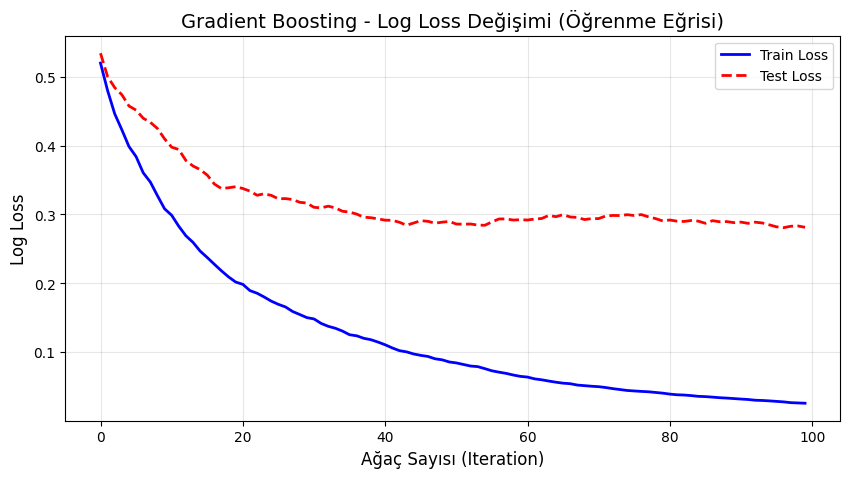

LightGBM eğitiliyor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56, number of negative: 164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2358
[LightGBM] [Info] Number of data points in the train set: 220, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254545 -> initscore=-1.074515
[LightGBM] [Info] Start training from score -1.074515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

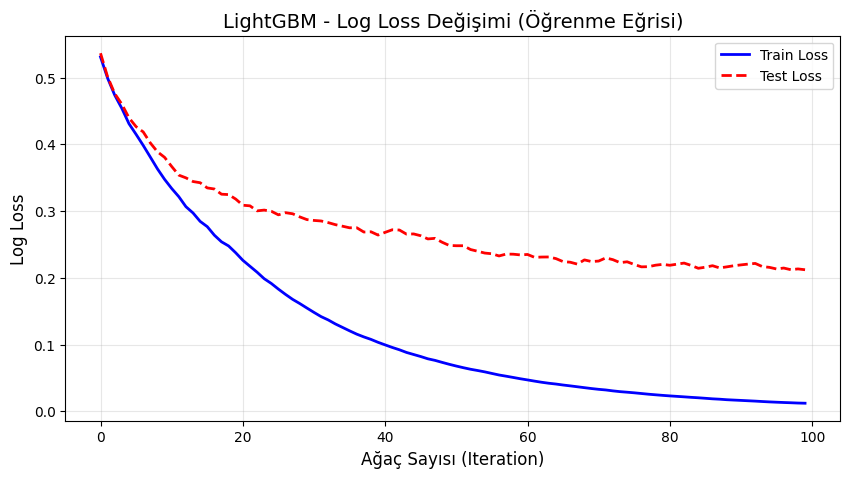

CatBoost eğitiliyor...


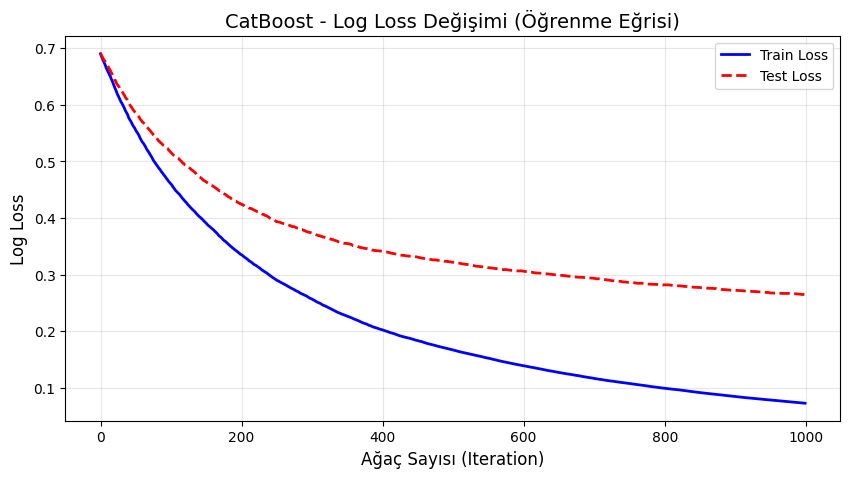

In [24]:
def plot_loss_curve(train_loss, test_loss, model_name):
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Train Loss', color='blue', linewidth=2)
    plt.plot(test_loss, label='Test Loss', color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name} - Log Loss Değişimi (Öğrenme Eğrisi)', fontsize=14)
    plt.xlabel('Ağaç Sayısı (Iteration)', fontsize=12)
    plt.ylabel('Log Loss', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 1. GRADIENT BOOSTING (Scikit-Learn)
# ==========================================
print("Gradient Boosting eğitiliyor...")
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Her adımda log loss hesaplama (staged_predict_proba ile)
gb_train_loss = [log_loss(y_train, y_prob) for y_prob in gb_model.staged_predict_proba(X_train)]
gb_test_loss = [log_loss(y_test, y_prob) for y_prob in gb_model.staged_predict_proba(X_test)]

plot_loss_curve(gb_train_loss, gb_test_loss, "Gradient Boosting")

# ==========================================
# 2. LIGHTGBM
# ==========================================
print("LightGBM eğitiliyor...")
# LightGBM'de içsel logları tutmak için eval_set kullanıyoruz
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'test'],
    eval_metric='binary_logloss',
    # verbose=-1  # Çıktı kirliliğini engellemek için
)

lgbm_results = lgb_model.evals_result_
lgb_train_loss = lgbm_results['train']['binary_logloss']
lgb_test_loss = lgbm_results['test']['binary_logloss']

plot_loss_curve(lgb_train_loss, lgb_test_loss, "LightGBM")

# ==========================================
# 3. CATBOOST
# ==========================================
print("CatBoost eğitiliyor...")
cb_model = CatBoostClassifier(random_seed=42, verbose=False)
cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=False # Tüm ağaçları görmek için
)

cb_results = cb_model.get_evals_result()
cb_train_loss = cb_results['learn']['Logloss']
cb_test_loss = cb_results['validation']['Logloss']

plot_loss_curve(cb_train_loss, cb_test_loss, "CatBoost")

Gradient Boosting (Default) eğitiliyor...


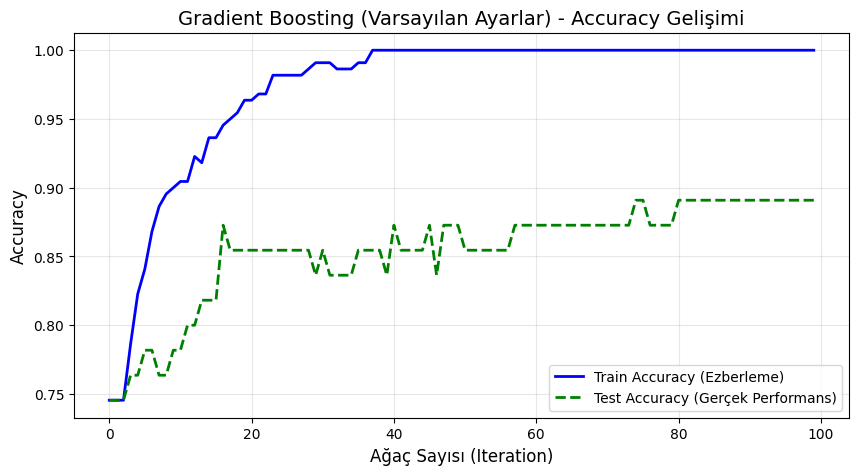

LightGBM (Default) eğitiliyor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56, number of negative: 164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2358
[LightGBM] [Info] Number of data points in the train set: 220, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254545 -> initscore=-1.074515
[LightGBM] [Info] Start training from score -1.074515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

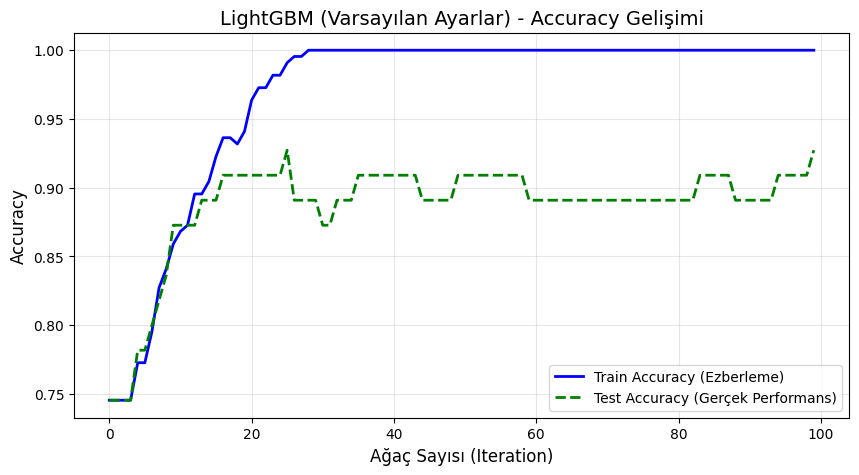

CatBoost (Default) eğitiliyor...


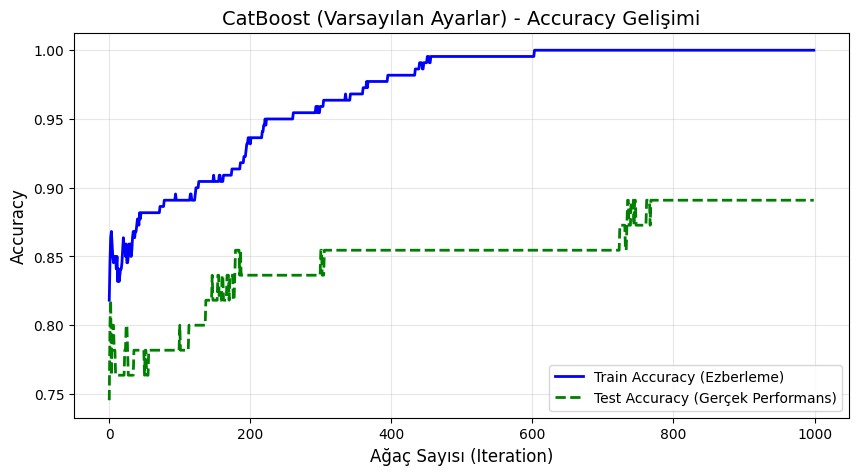

In [25]:
def plot_default_accuracy(train_acc, test_acc, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy (Ezberleme)', color='blue', linewidth=2)
    plt.plot(test_acc, label='Test Accuracy (Gerçek Performans)', color='green', linestyle='--', linewidth=2)
    plt.title(f'{title} (Varsayılan Ayarlar) - Accuracy Gelişimi', fontsize=14)
    plt.xlabel('Ağaç Sayısı (Iteration)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 1. GRADIENT BOOSTING (Sadece random_state=42)
# ==========================================
print("Gradient Boosting (Default) eğitiliyor...")
gb_def = GradientBoostingClassifier(random_state=42)
gb_def.fit(X_train, y_train)

# Adım adım accuracy hesaplama
gb_train_acc = [accuracy_score(y_train, y_pred) for y_pred in gb_def.staged_predict(X_train)]
gb_test_acc = [accuracy_score(y_test, y_pred) for y_pred in gb_def.staged_predict(X_test)]

plot_default_accuracy(gb_train_acc, gb_test_acc, "Gradient Boosting")

# ==========================================
# 2. LIGHTGBM (Sadece random_state=42)
# ==========================================
print("LightGBM (Default) eğitiliyor...")
lgb_def = lgb.LGBMClassifier(random_state=42)

# HATA DÜZELTİLDİ: verbose silindi, eval_metric eklendi
lgb_def.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='binary_error',
    # log_evaluation callback'i ile çıktıları kontrol edebilirsin (isteğe bağlı)
    callbacks=[lgb.log_evaluation(period=0)]
)

lgbm_results = lgb_def.evals_result_
# Error'dan Accuracy'ye çevirme (1 - error)
# LightGBM default olarak 'training' ve 'valid_1' isimlerini kullanır
lgb_train_acc = [1 - x for x in lgbm_results['training']['binary_error']]
lgb_test_acc = [1 - x for x in lgbm_results['valid_1']['binary_error']]

plot_default_accuracy(lgb_train_acc, lgb_test_acc, "LightGBM")

# ==========================================
# 3. CATBOOST (Sadece random_seed=42)
# ==========================================
print("CatBoost (Default) eğitiliyor...")
cb_def = CatBoostClassifier(random_seed=42, verbose=False, eval_metric='Accuracy')
cb_def.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=False)

cb_results = cb_def.get_evals_result()
cb_train_acc = cb_results['learn']['Accuracy']
cb_test_acc = cb_results['validation']['Accuracy']

plot_default_accuracy(cb_train_acc, cb_test_acc, "CatBoost")

gb_params = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 1.0],
    "min_samples_split": [2, 5, 10]
}

lgbm_params = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "num_leaves": [3, 7, 15, 31, 63],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 0.1, 0.5]
}

cb_params = {
    "iterations": [50, 100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 1.0],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "random_strength": [1, 5]
}
# -------------------------
# Models list (tuning)
# -------------------------
randomcv_models = [
    ("GradientBoosting", GradientBoostingClassifier(random_state=42), gb_params),
    ("LightGBM", lgb.LGBMClassifier(random_state=42), lgbm_params),
    ("CatBoost", CatBoostClassifier(random_seed=42, verbose=False), cb_params),
]

# -------------------------
# RandomizedSearchCV
# -------------------------
model_param = {}
model_score = {}

for name, model, params in randomcv_models:
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=40,                 # son deneme için 40 mantıklı, istersen 100 yap
        cv=3,
        scoring="neg_log_loss",
        verbose=2,
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train, y_train)

    model_param[name] = search.best_params_
    model_score[name] = search.best_score_

for model_name in model_param:
    print(f"\n---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])
    print(f"Best CV neg_log_loss: {model_score[model_name]:.5f}")

In [26]:
models = {
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42,
        subsample=0.85,
        n_estimators=100,
        min_samples_split=2,
        min_samples_leaf=4,
        max_depth=2,
        learning_rate=0.05
    ),
    "LightGBM": lgb.LGBMClassifier(
        random_state=42,
        subsample=0.85,
        reg_lambda=0.0,
        reg_alpha=0.0,
        num_leaves=15,
        n_estimators=150,
        min_child_samples=10,
        max_depth=2,
        learning_rate=0.05,
        colsample_bytree=0.7
    ),
    "CatBoost": CatBoostClassifier(
        random_seed=42,
        subsample=0.7,      # GÜNCELLENDİ
        learning_rate=0.1,
        l2_leaf_reg=3,      # GÜNCELLENDİ
        iterations=50,
        depth=4,            # GÜNCELLENDİ
        verbose=False
    )
}

def print_classification_metrics(y_true, y_pred):
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.3f}")

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    print(f"\n================ {name} =================")
    print("Train Metrics")
    print_classification_metrics(y_train, y_train_pred)

    print("\nTest Metrics")
    print_classification_metrics(y_test, y_test_pred)




================ GradientBoosting =================
Train Metrics
Accuracy : 0.959
Precision: 1.000
Recall   : 0.839
F1 Score : 0.913

Test Metrics
Accuracy : 0.855
Precision: 0.750
Recall   : 0.643
F1 Score : 0.692
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56, number of negative: 164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2358
[LightGBM] [Info] Number of data points in the train set: 220, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254545 -> initscore=-1.074515
[LightGBM] [Info] Start training from score -1.074515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Gradient Boosting Best Params ile eğitiliyor...


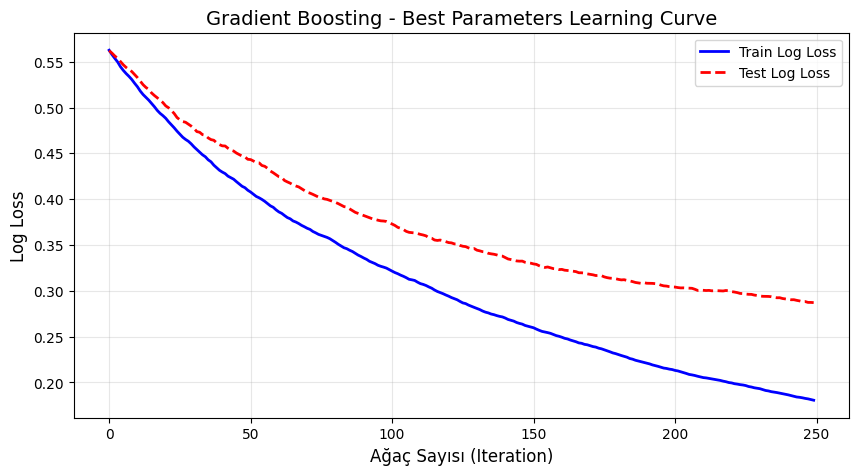

LightGBM Best Params ile eğitiliyor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56, number of negative: 164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2358
[LightGBM] [Info] Number of data points in the train set: 220, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254545 -> initscore=-1.074515
[LightGBM] [Info] Start training from score -1.074515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

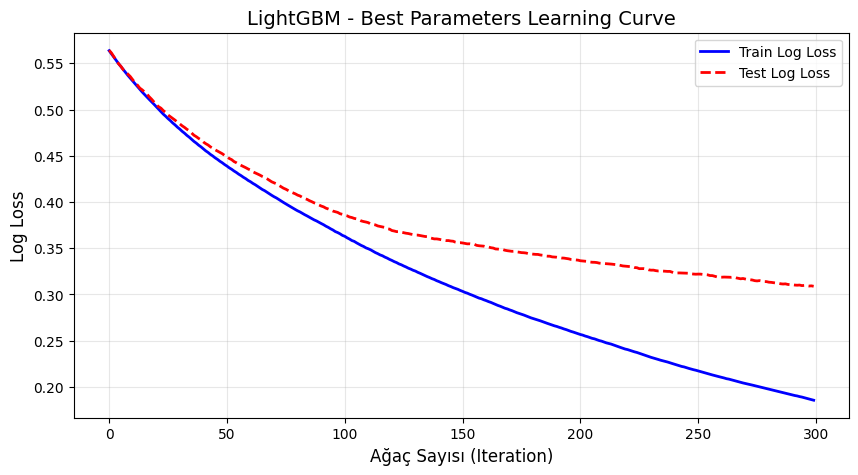

CatBoost Best Params ile eğitiliyor...


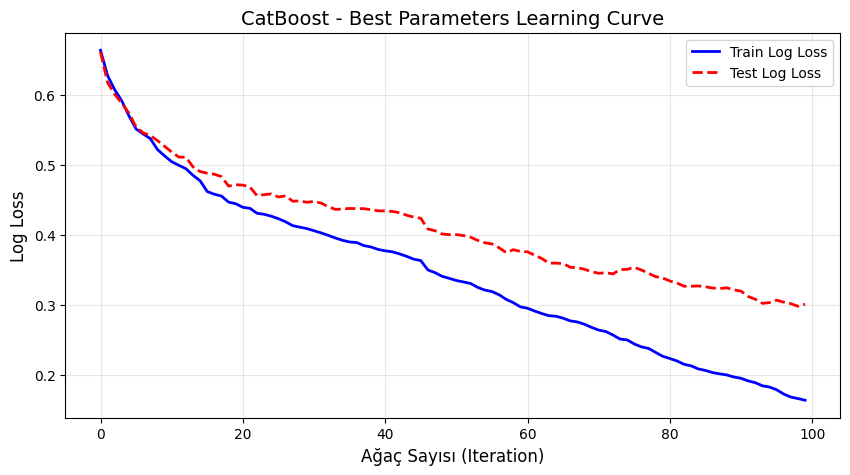

In [27]:
def plot_best_model_learning_curve(train_loss, test_loss, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Train Log Loss', color='blue', linewidth=2)
    plt.plot(test_loss, label='Test Log Loss', color='red', linestyle='--', linewidth=2)
    plt.title(f'{title} - Best Parameters Learning Curve', fontsize=14)
    plt.xlabel('Ağaç Sayısı (Iteration)', fontsize=12)
    plt.ylabel('Log Loss', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 1. GRADIENT BOOSTING (Best Params)
# ==========================================
print("Gradient Boosting Best Params ile eğitiliyor...")
gb_best = GradientBoostingClassifier(
    random_state=42,
    subsample=0.7,
    n_estimators=250,
    min_samples_split=2,
    max_depth=3,
    learning_rate=0.01
)
gb_best.fit(X_train, y_train)

# Kayıpları hesapla
gb_train_loss = [log_loss(y_train, p) for p in gb_best.staged_predict_proba(X_train)]
gb_test_loss = [log_loss(y_test, p) for p in gb_best.staged_predict_proba(X_test)]

plot_best_model_learning_curve(gb_train_loss, gb_test_loss, "Gradient Boosting")

# ==========================================
# 2. LIGHTGBM (Best Params)
# ==========================================
print("LightGBM Best Params ile eğitiliyor...")
lgb_best = lgb.LGBMClassifier(
    random_state=42,
    subsample=0.7,
    reg_lambda=0.1,
    reg_alpha=0.5,
    num_leaves=15,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.01,
    colsample_bytree=1.0
)
lgb_best.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'test'],
    eval_metric='binary_logloss'
)

lgbm_results = lgb_best.evals_result_
plot_best_model_learning_curve(lgbm_results['train']['binary_logloss'],
                               lgbm_results['test']['binary_logloss'], "LightGBM")

# ==========================================
# 3. CATBOOST (Best Params)
# ==========================================
print("CatBoost Best Params ile eğitiliyor...")
cb_best = CatBoostClassifier(
    random_seed=42,
    subsample=0.8,
    random_strength=5,
    learning_rate=0.1,
    l2_leaf_reg=7,
    iterations=100,
    depth=3,
    verbose=False
)
cb_best.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=False)

cb_results = cb_best.get_evals_result()
plot_best_model_learning_curve(cb_results['learn']['Logloss'],
                               cb_results['validation']['Logloss'], "CatBoost")

Gradient Boosting Accuracy analizi yapılıyor...


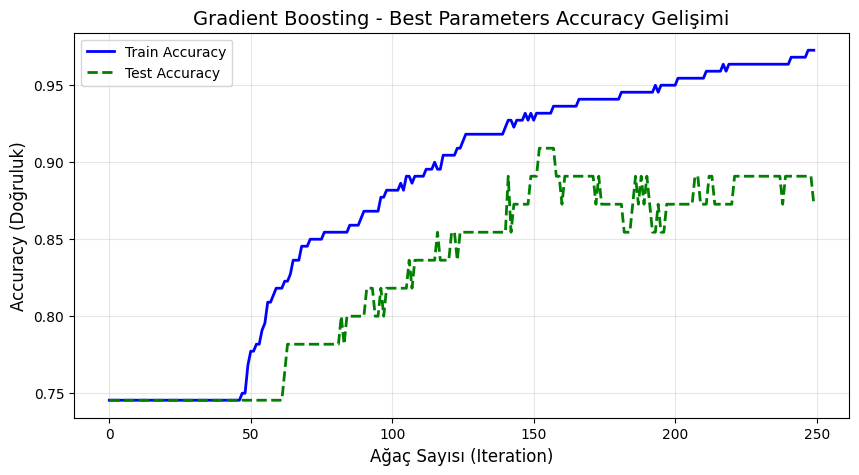

LightGBM Accuracy analizi yapılıyor...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 56, number of negative: 164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2358
[LightGBM] [Info] Number of data points in the train set: 220, number of used features: 32
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254545 -> initscore=-1.074515
[LightGBM] [Info] Start training from score -1.074515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

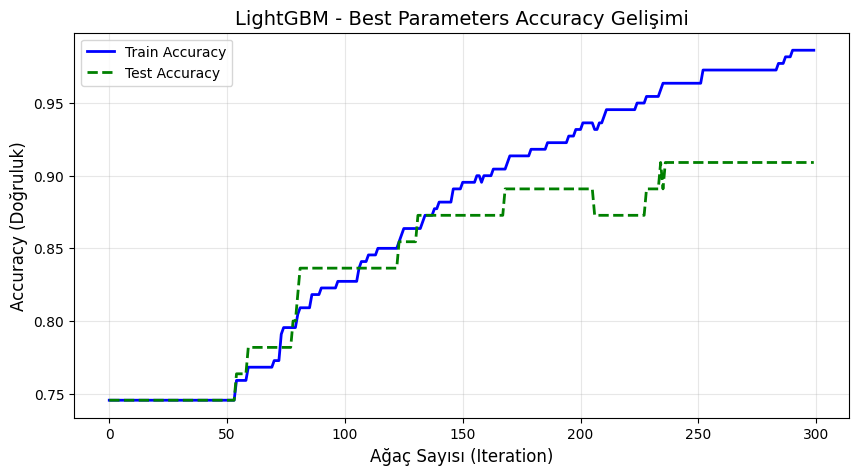

CatBoost Accuracy analizi yapılıyor...


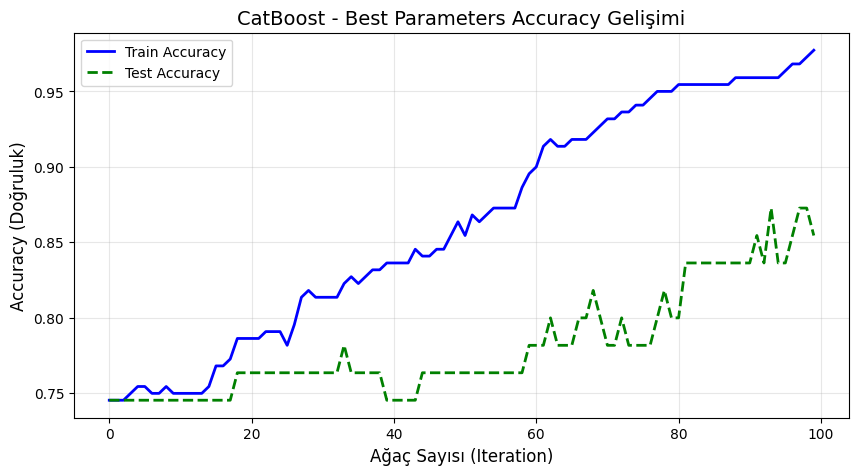

In [28]:
def plot_accuracy_curve(train_acc, test_acc, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy', color='blue', linewidth=2)
    plt.plot(test_acc, label='Test Accuracy', color='green', linestyle='--', linewidth=2)
    plt.title(f'{title} - Best Parameters Accuracy Gelişimi', fontsize=14)
    plt.xlabel('Ağaç Sayısı (Iteration)', fontsize=12)
    plt.ylabel('Accuracy (Doğruluk)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# 1. GRADIENT BOOSTING (Best Params)
# ==========================================
print("Gradient Boosting Accuracy analizi yapılıyor...")
gb_best = GradientBoostingClassifier(
    random_state=42,
    subsample=0.7,
    n_estimators=250,
    min_samples_split=2,
    max_depth=3,
    learning_rate=0.01
)
gb_best.fit(X_train, y_train)

# Her adımda Accuracy hesapla (staged_predict ile)
gb_train_acc = [accuracy_score(y_train, y_pred) for y_pred in gb_best.staged_predict(X_train)]
gb_test_acc = [accuracy_score(y_test, y_pred) for y_pred in gb_best.staged_predict(X_test)]

plot_accuracy_curve(gb_train_acc, gb_test_acc, "Gradient Boosting")

# ==========================================
# 2. LIGHTGBM (Best Params)
# ==========================================
print("LightGBM Accuracy analizi yapılıyor...")
lgb_best = lgb.LGBMClassifier(
    random_state=42,
    subsample=0.7,
    reg_lambda=0.1,
    reg_alpha=0.5,
    num_leaves=15,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.01,
    colsample_bytree=1.0
)

# LightGBM'de accuracy (1 - error) olarak takip edilir
lgb_best.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='binary_error' # binary_error = 1 - Accuracy
)

results = lgb_best.evals_result_
# Error'dan Accuracy'ye çeviriyoruz (1 - error)
lgb_train_acc = [1 - x for x in results['training']['binary_error']]
lgb_test_acc = [1 - x for x in results['valid_1']['binary_error']]

plot_accuracy_curve(lgb_train_acc, lgb_test_acc, "LightGBM")

# ==========================================
# 3. CATBOOST (Best Params)
# ==========================================
print("CatBoost Accuracy analizi yapılıyor...")
cb_best = CatBoostClassifier(
    random_seed=42,
    subsample=0.8,
    random_strength=5,
    learning_rate=0.1,
    l2_leaf_reg=7,
    iterations=100,
    depth=3,
    eval_metric='Accuracy', # Doğrudan Accuracy takip etmesini söylüyoruz
    verbose=False
)
cb_best.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=False)

cb_results = cb_best.get_evals_result()
cb_train_acc = cb_results['learn']['Accuracy']
cb_test_acc = cb_results['validation']['Accuracy']

plot_accuracy_curve(cb_train_acc, cb_test_acc, "CatBoost")